# Exploratory Data Analysis (EDA)

## Overview

This notebook explores the cleaned HR Analytics dataset to identify trends, patterns, and key factors influencing employee attrition. The analysis helps understand employee behavior and provides business insights that can support HR decision-making.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv(r"C:\Users\hp\cleaned_hr_data.csv")

In [14]:
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,3,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,3,1,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,3,4,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,3,4,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,3,4,0,0,0,3,0,0,0,0.0


In [18]:
df.shape

(1473, 35)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1473 non-null   object 
 1   Age                       1473 non-null   int64  
 2   AgeGroup                  1473 non-null   object 
 3   Attrition                 1473 non-null   object 
 4   BusinessTravel            1473 non-null   object 
 5   DailyRate                 1473 non-null   int64  
 6   Department                1473 non-null   object 
 7   DistanceFromHome          1473 non-null   int64  
 8   Education                 1473 non-null   int64  
 9   EducationField            1473 non-null   object 
 10  EmployeeNumber            1473 non-null   int64  
 11  EnvironmentSatisfaction   1473 non-null   int64  
 12  Gender                    1473 non-null   object 
 13  HourlyRate                1473 non-null   int64  
 14  JobInvol

## 1. What is the Overall Employee Attrition Rate?

### Objective
Analyze the distribution of employee attrition to understand how many employees have left the company and how many are still working.

In [23]:
df["Attrition"].value_counts()

Attrition
No     1236
Yes     237
Name: count, dtype: int64

In [25]:
(df["Attrition"].value_counts(normalize=True) * 100).round(2)

Attrition
No     83.91
Yes    16.09
Name: proportion, dtype: float64

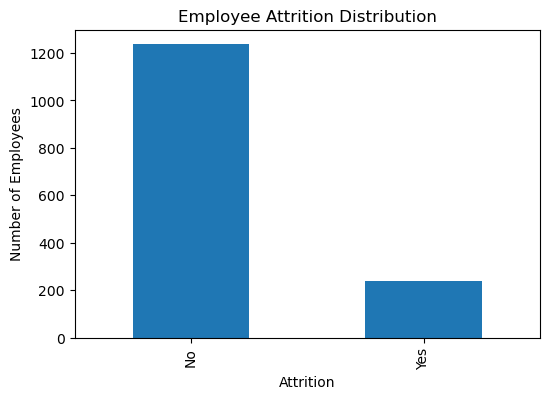

In [27]:
attrition_count = df["Attrition"].value_counts()

plt.figure(figsize=(6,4))
attrition_count.plot(kind="bar")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

### Insight

The attrition distribution shows that most employees are retained by the company, while a smaller percentage have left. Understanding the attrition rate is the first step in identifying factors

## 2. Which Department Has the Highest Employee Attrition?

### Objective

Analyze employee attrition across different departments to identify which department experiences the highest employee turnover.

In [32]:
department_attrition = pd.crosstab(df["Department"], df["Attrition"])

department_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,830,133
Sales,355,92


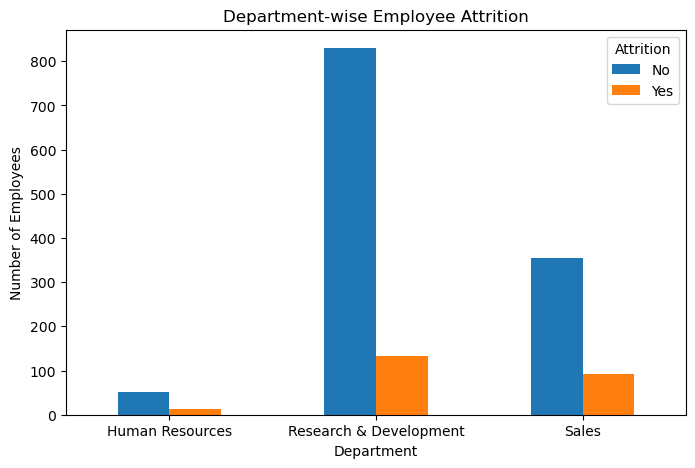

In [34]:
department_attrition.plot(kind="bar", figsize=(8,5))

plt.title("Department-wise Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.show()

In [36]:
department_percentage = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_percentage.round(2)

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.19,13.81
Sales,79.42,20.58


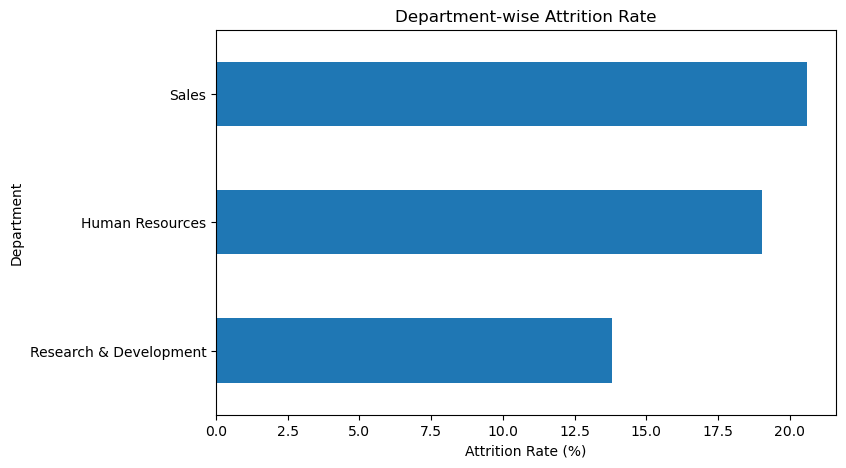

In [47]:
department_percentage["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Department-wise Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.show()

### Insight

The **Sales** department has the highest employee attrition rate, indicating that employees in this department are more likely to leave the organization. Although the **Research & Development** department recorded the highest number of employee exits, it also has the largest workforce. Therefore, the **attrition rate** provides a more meaningful comparison than the total attrition count. These findings suggest that the Sales department requires greater attention to improve employee retention.

### Business Recommendation

The HR team should focus on identifying the key reasons behind the high attrition rate in the Sales department. Initiatives such as employee engagement programs, career development opportunities, performance recognition, and workload management can help improve employee satisfaction and reduce turnover.

## 3. Does Overtime Affect Employee Attrition?

### Objective

Analyze the relationship between overtime and employee attrition to determine whether employees who work overtime are more likely to leave the company.

In [43]:
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"])

overtime_attrition

Attrition,No,Yes
OverTime,,
No,947,110
Yes,289,127


In [45]:
overtime_percentage = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

overtime_percentage.round(2)

Attrition,No,Yes
OverTime,,
No,89.59,10.41
Yes,69.47,30.53


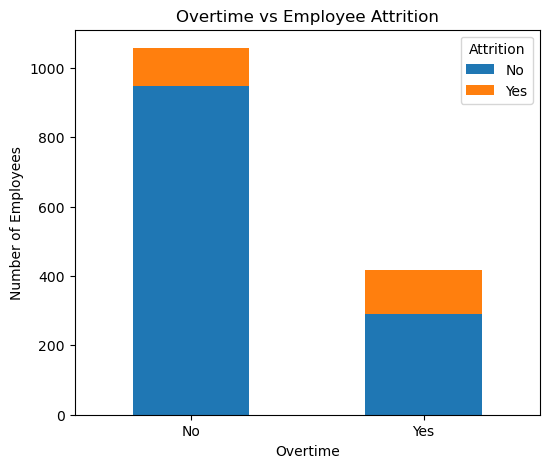

In [49]:
overtime_attrition.plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Overtime vs Employee Attrition")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.legend(title="Attrition")
plt.show()

### Insight

Employees who work overtime have a significantly higher attrition rate (**30.53%**) compared to employees who do not work overtime (**10.41%**). This indicates that excessive workload and longer working hours may contribute to employee dissatisfaction and increase the likelihood of employees leaving the organization.

### Business Recommendation

The HR team should monitor employees who frequently work overtime and implement workload balancing, flexible work policies, and employee wellness programs to improve work-life balance and reduce employee attrition.

## 4. Does Gender Influence Employee Attrition?

### Objective

Analyze employee attrition across different genders to determine whether gender has a significant impact on employee turnover.

In [57]:
gender_attrition = pd.crosstab(df["Gender"], df["Attrition"])

gender_attrition

Attrition,No,Yes
Gender,,
Female,502,87
Male,734,150


In [59]:
gender_percentage = pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
) * 100

gender_percentage.round(2)

Attrition,No,Yes
Gender,,
Female,85.23,14.77
Male,83.03,16.97


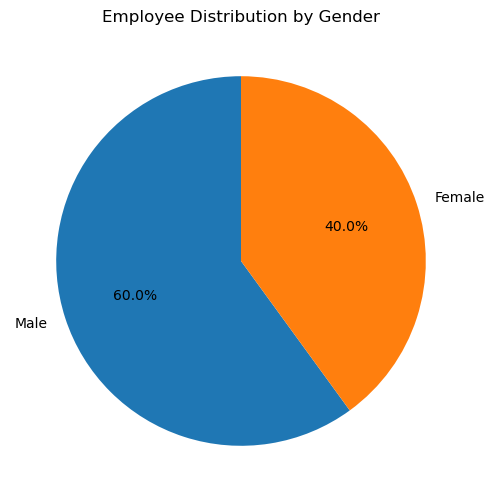

In [61]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Employee Distribution by Gender")

plt.show()

### Insight

Male employees have a slightly higher attrition rate (**16.97%**) compared to female employees (**14.77%**). The difference is relatively small, suggesting that gender is not a major factor influencing employee attrition. Other factors such as overtime, job satisfaction, salary, and work-life balance are likely to have a greater impact on employee turnover.

### Business Recommendation

Since the difference in attrition rates between male and female employees is minimal, HR should focus on improving workplace factors that affect all employees, such as workload management, career growth opportunities, employee engagement, and work-life balance, rather than implementing gender-specific retention strategies.

## 5. Which Age Group Has the Highest Employee Attrition?

### Objective

Analyze employee attrition across different age groups to identify which age group has the highest employee turnover. This analysis helps HR understand whether attrition is concentrated among employees at a particular career stage.

In [66]:
age_attrition = pd.crosstab(df["AgeGroup"], df["Attrition"])

age_attrition

Attrition,No,Yes
AgeGroup,,
18-25,79,44
26-35,491,116
36-45,427,43
46-55,200,26
55+,39,8


In [68]:
age_percentage = pd.crosstab(
    df["AgeGroup"],
    df["Attrition"],
    normalize="index"
) * 100

age_percentage.round(2)

Attrition,No,Yes
AgeGroup,,
18-25,64.23,35.77
26-35,80.89,19.11
36-45,90.85,9.15
46-55,88.50,11.50
55+,82.98,17.02


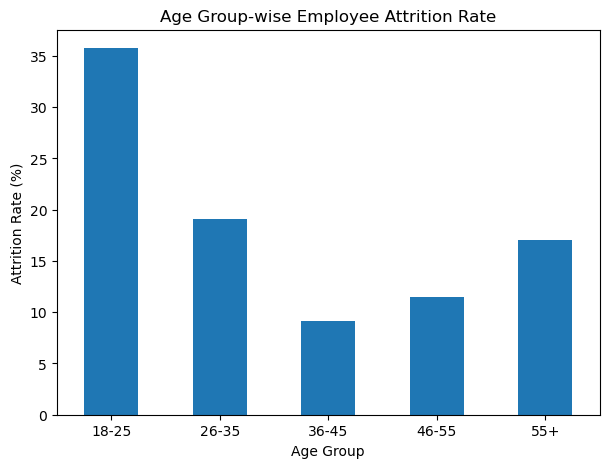

In [70]:
age_percentage["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Age Group-wise Employee Attrition Rate")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Insight

Employees aged **18–25** have the highest attrition rate (**35.77%**), indicating that younger employees are the most likely to leave the organization. The attrition rate gradually decreases for employees aged **26–35 (19.11%)** and reaches its lowest among employees aged **36–45 (9.15%)**. This suggests that younger employees may leave more frequently due to career growth opportunities, higher education, or job changes, while mid-career employees tend to have greater job stability.

### Business Recommendation

The HR team should focus on retaining younger employees by offering structured onboarding, career development programs, mentorship opportunities, skill enhancement, and clear promotion paths. These initiatives can improve employee engagement and reduce early-career attrition.

## 6. Does Salary Influence Employee Attrition?

### Objective

Analyze employee attrition across different salary slabs to determine whether salary has an impact on employee turnover. This analysis helps identify whether employees with lower salaries are more likely to leave the organization.

In [75]:
salary_attrition = pd.crosstab(df["SalarySlab"], df["Attrition"])

salary_attrition

Attrition,No,Yes
SalarySlab,,
10k-15k,128,20
15k+,128,5
5k-10k,392,49
Upto 5k,588,163


In [77]:
salary_percentage = pd.crosstab(
    df["SalarySlab"],
    df["Attrition"],
    normalize="index"
) * 100

salary_percentage.round(2)

Attrition,No,Yes
SalarySlab,,
10k-15k,86.49,13.51
15k+,96.24,3.76
5k-10k,88.89,11.11
Upto 5k,78.30,21.70


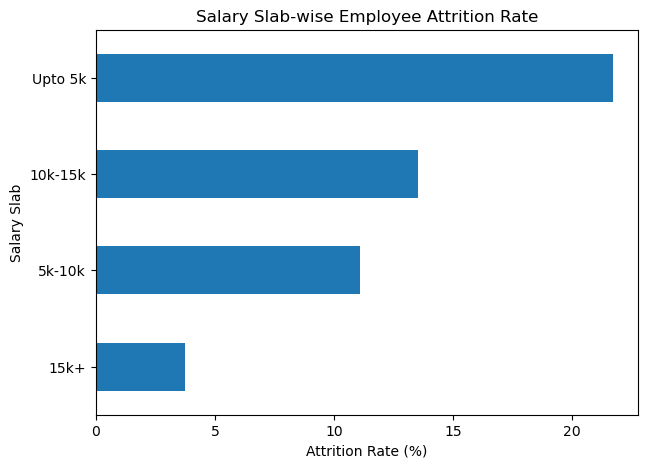

In [79]:
salary_percentage["Yes"].sort_values().plot(
    kind="barh",
    figsize=(7,5)
)

plt.title("Salary Slab-wise Employee Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Salary Slab")

plt.show()

### Insight

Employees earning **up to 5k** have the highest attrition rate (**21.70%**), indicating that lower-paid employees are more likely to leave the organization. As salary increases, the attrition rate decreases significantly. Employees earning **15k+** have the lowest attrition rate (**3.76%**), suggesting that competitive compensation plays an important role in improving employee retention.

### Business Recommendation

The HR team should review the compensation and benefits offered to employees in the lower salary slabs. Providing competitive salaries, performance-based incentives, career growth opportunities, and employee recognition programs can help improve job satisfaction and reduce attrition among lower-paid employees.

## 7. Which Job Role Has the Highest Employee Attrition?

### Objective

Analyze employee attrition across different job roles to identify which roles experience the highest employee turnover. This analysis helps the HR team identify critical job roles that require targeted retention strategies.

In [84]:
jobrole_attrition = pd.crosstab(df["JobRole"], df["Attrition"])

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,123,9
Human Resources,40,12
Laboratory Technician,198,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,51,33


In [86]:
jobrole_percentage = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_percentage.round(2)

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.18,6.82
Human Resources,76.92,23.08
Laboratory Technician,76.15,23.85
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.52,17.48
Sales Representative,60.71,39.29


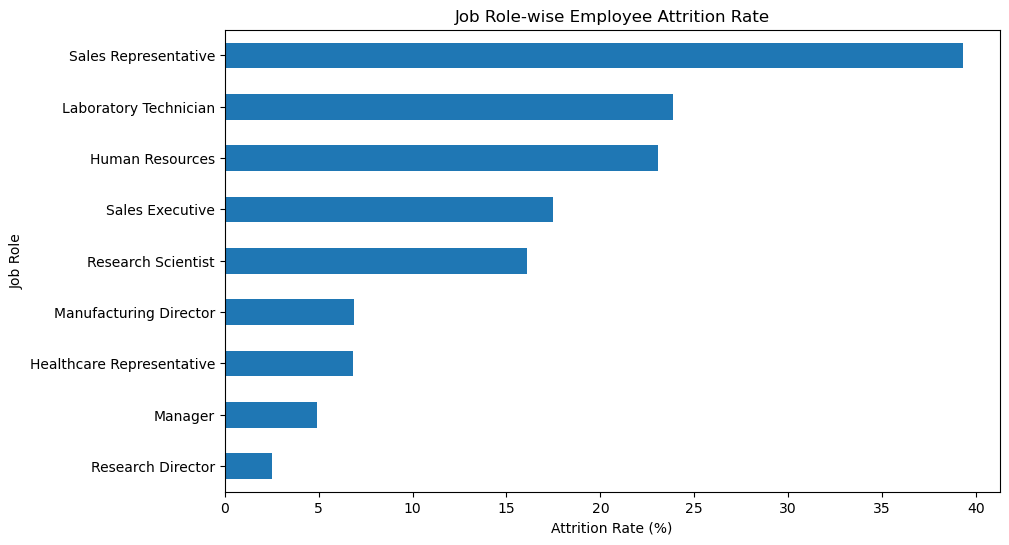

In [88]:
jobrole_percentage["Yes"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Job Role-wise Employee Attrition Rate")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

### Insight

The **Sales Representative** role has the highest employee attrition rate (**39.29%**), followed by **Laboratory Technician (23.85%)** and **Human Resources (23.08%)**. In contrast, **Research Director (2.50%)** and **Manager (4.90%)** have the lowest attrition rates. This indicates that employees in entry-level and customer-facing roles are more likely to leave the organization, whereas senior and leadership positions show much higher employee retention.

### Business Recommendation

The HR team should prioritize retention strategies for high-attrition job roles, particularly **Sales Representatives**, **Laboratory Technicians**, and **Human Resources**. Improving compensation, providing clear career growth opportunities, strengthening employee engagement, and offering role-specific training can help reduce turnover in these critical positions.

## 8. Does Job Satisfaction Affect Employee Attrition?

### Objective

Analyze the relationship between job satisfaction and employee attrition to determine whether employees with lower job satisfaction are more likely to leave the organization.

In [93]:
job_satisfaction = pd.crosstab(df["JobSatisfaction"], df["Attrition"])

job_satisfaction

Attrition,No,Yes
JobSatisfaction,,
1,224,66
2,234,46
3,370,73
4,408,52


In [95]:
job_satisfaction_percentage = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

job_satisfaction_percentage.round(2)


Attrition,No,Yes
JobSatisfaction,,
1,77.24,22.76
2,83.57,16.43
3,83.52,16.48
4,88.70,11.30


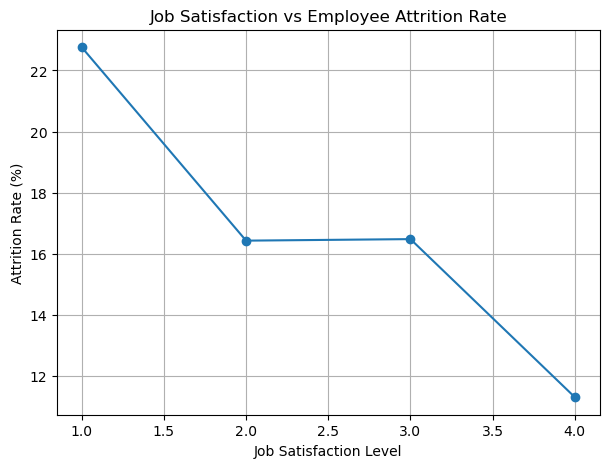

In [97]:
job_satisfaction_percentage["Yes"].plot(
    kind="line",
    marker="o",
    figsize=(7,5)
)

plt.title("Job Satisfaction vs Employee Attrition Rate")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)

plt.show()

### Insight

Employees with the **lowest job satisfaction (Level 1)** have the highest attrition rate (**22.76%**), while employees with the **highest job satisfaction (Level 4)** have the lowest attrition rate (**11.30%**). The analysis indicates a negative relationship between job satisfaction and employee attrition, suggesting that employees who are more satisfied with their jobs are less likely to leave the organization.

### Business Recommendation

The HR team should focus on improving employee job satisfaction through regular feedback sessions, recognition and reward programs, career development opportunities, effective leadership, and a positive work environment. Enhancing job satisfaction can help reduce employee attrition and improve long-term employee retention.

## 9. Does Work-Life Balance Affect Employee Attrition?

### Objective

Analyze the relationship between work-life balance and employee attrition to determine whether employees with poor work-life balance are more likely to leave the organization.

In [102]:
worklife_attrition = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"]
)

worklife_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,769,127
4,126,27


In [104]:
worklife_percentage = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

worklife_percentage.round(2)

Attrition,No,Yes
WorkLifeBalance,,
1,68.75,31.25
2,83.14,16.86
3,85.83,14.17
4,82.35,17.65


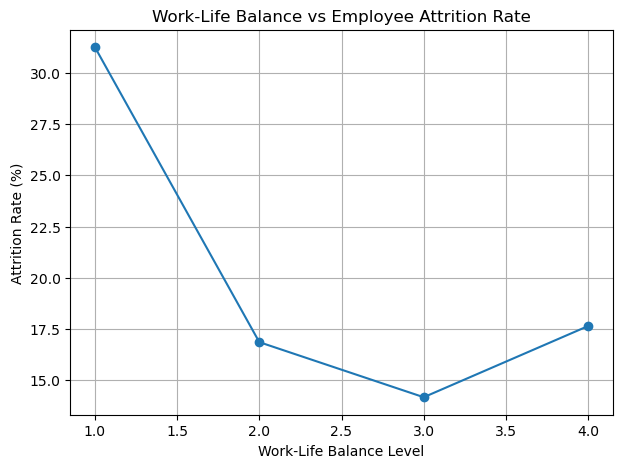

In [106]:
worklife_percentage["Yes"].plot(
    kind="line",
    marker="o",
    figsize=(7,5)
)

plt.title("Work-Life Balance vs Employee Attrition Rate")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)

plt.show()

### Insight

Employees with the **lowest Work-Life Balance (Level 1)** have the highest attrition rate (**31.25%**), indicating that poor work-life balance significantly increases the likelihood of employees leaving the organization. Attrition decreases at **Level 2 (16.86%)** and reaches its lowest at **Level 3 (14.17%)**. Although **Level 4** shows a slightly higher attrition rate (**17.65%**) than Level 3, employees with a balanced work-life generally demonstrate better retention than those with poor work-life balance.

### Business Recommendation

The HR team should improve employees' work-life balance by promoting flexible work arrangements, managing workloads effectively, encouraging regular leave utilization, and implementing employee wellness initiatives. These measures can help reduce employee stress, improve job satisfaction, and lower employee attrition.

## 10. Correlation Analysis

### Objective

Analyze the relationships between numerical features using a correlation matrix to identify variables that are positively or negatively related. This helps understand employee characteristics and supports better business decision-making.

In [111]:
import seaborn as sns


In [113]:
numerical_df = df.select_dtypes(include=["int64", "float64"])

In [115]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.009831,-0.001441,0.207328,-0.011354,0.009346,0.025559,0.030303,0.509977,-0.005404,...,0.002212,0.052204,0.038256,0.680300,-0.018831,-0.021722,0.311535,0.213357,0.216867,0.206627
DailyRate,0.009831,1.000000,-0.004936,-0.016249,-0.050079,0.018710,0.022450,0.045978,0.002095,0.031329,...,0.000289,0.009106,0.041497,0.014202,0.001544,-0.037684,-0.034384,0.009217,-0.033597,-0.022419
DistanceFromHome,-0.001441,-0.004936,1.000000,0.020427,0.033703,-0.016472,0.030552,0.011455,0.005338,-0.001994,...,0.026845,0.006854,0.045349,0.005834,-0.036918,-0.026341,0.009290,0.018115,0.009566,0.014296
Education,0.207328,-0.016249,0.020427,1.000000,0.038768,-0.028630,0.018839,0.042461,0.100291,-0.009961,...,-0.023726,-0.007177,0.017881,0.147879,-0.027329,0.009191,0.069176,0.059486,0.054994,0.067072
EmployeeNumber,-0.011354,-0.050079,0.033703,0.038768,1.000000,0.020571,0.030158,-0.007165,-0.018653,-0.046246,...,-0.021784,-0.069707,0.061498,-0.014740,0.024955,0.011458,-0.012161,-0.008928,-0.011000,0.006323
EnvironmentSatisfaction,0.009346,0.018710,-0.016472,-0.028630,0.020571,1.000000,-0.052249,-0.009575,0.001108,-0.007619,...,-0.030264,0.007382,0.002922,-0.003436,-0.018430,0.028193,0.001009,0.017995,0.015224,0.003932
HourlyRate,0.025559,0.022450,0.030552,0.018839,0.030158,-0.052249,1.000000,0.043260,-0.027256,-0.071100,...,-0.000964,0.000941,0.050867,-0.001739,-0.009266,-0.005552,-0.018679,-0.023408,-0.024982,-0.001269
JobInvolvement,0.030303,0.045978,0.011455,0.042461,-0.007165,-0.009575,0.043260,1.000000,-0.012590,-0.019093,...,-0.028937,0.034784,0.022251,-0.003863,-0.015861,-0.014650,-0.021369,0.007847,-0.024226,0.037231
JobLevel,0.509977,0.002095,0.005338,0.100291,-0.018653,0.001108,-0.027256,-0.012590,1.000000,-0.003047,...,-0.021156,0.019902,0.014710,0.781761,-0.016780,0.037752,0.534710,0.389918,0.353819,0.367207
JobSatisfaction,-0.005404,0.031329,-0.001994,-0.009961,-0.046246,-0.007619,-0.071100,-0.019093,-0.003047,1.000000,...,0.002342,-0.010328,0.010449,-0.019397,-0.007564,-0.019470,-0.004135,-0.003700,-0.018436,-0.030717


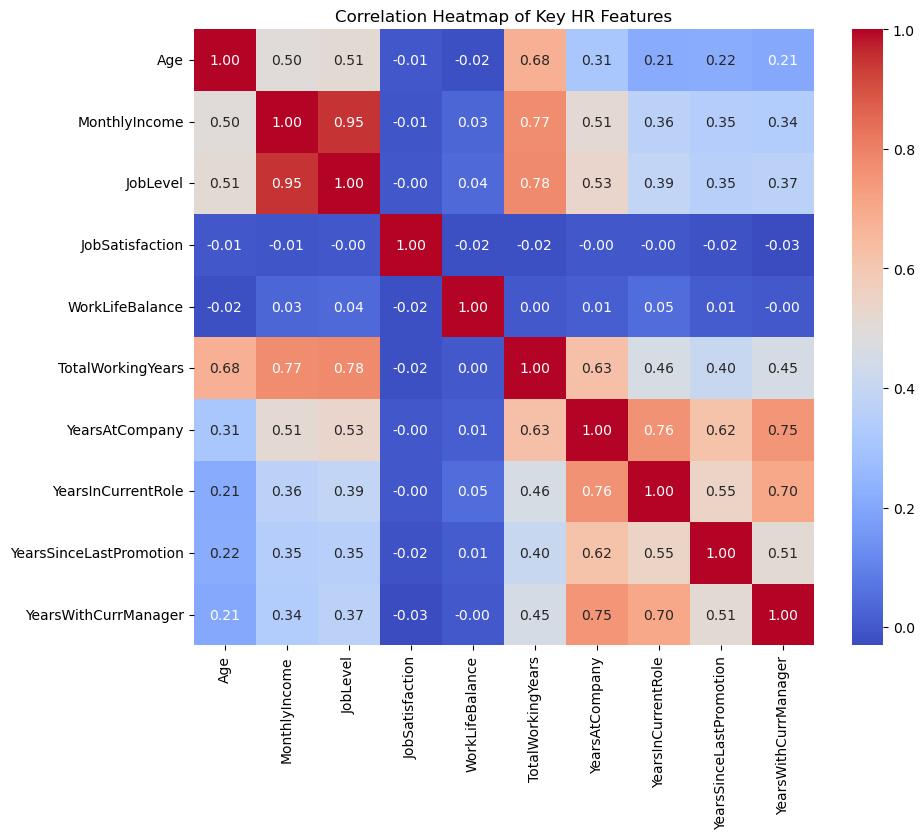

In [119]:
columns = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "JobSatisfaction",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

corr = df[columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Key HR Features")

plt.show()

### Insight

The heatmap shows a **strong positive correlation** between **Monthly Income** and **Job Level (0.95)**, indicating that employees at higher job levels generally earn higher salaries. **Total Working Years** is also positively correlated with **Monthly Income (0.77)** and **Job Level (0.78)**, suggesting that experienced employees tend to hold senior positions with better compensation. Additionally, **Years at Company**, **Years in Current Role**, and **Years with Current Manager** are moderately to strongly correlated, reflecting that employees who stay longer in the organization are more likely to remain in the same role and continue working with the same manager. On the other hand, **Job Satisfaction** and **Work-Life Balance** show very weak correlations with other numerical variables, indicating that these factors are influenced by aspects beyond age, salary, or experience.

### Business Recommendation

The HR team should continue supporting employee career progression through structured promotions, skill development, and competitive compensation, as experience and job level are closely associated with higher salaries. Since job satisfaction and work-life balance show weak relationships with numerical factors, the organization should also focus on non-monetary initiatives such as employee recognition, leadership support, career development, and workplace well-being to improve employee retention.

# Key Findings

- The overall employee attrition rate is **16.09%**, indicating that approximately one out of every six employees leaves the organization.
- The **Sales** department has the highest attrition rate, making it the department with the greatest employee turnover.
- Employees who work **overtime** have a significantly higher attrition rate (**30.53%**) compared to employees who do not (**10.41%**).
- Employees aged **18–25** show the highest attrition rate (**35.77%**), suggesting that younger employees are more likely to leave the organization.
- Employees in the **lowest salary slab (Up to 5k)** have the highest attrition rate (**21.70%**), while employees earning **15k+** have the lowest (**3.76%**).
- **Sales Representatives** experience the highest attrition rate (**39.29%**) among all job roles.
- Lower **job satisfaction** and poor **work-life balance** are associated with higher employee attrition.
- The correlation analysis shows that **Monthly Income**, **Job Level**, and **Total Working Years** are strongly positively correlated, while **Job Satisfaction** and **Work-Life Balance** have weak correlations with numerical features.

# Overall Business Recommendations

- Reduce excessive overtime by balancing employee workloads and promoting flexible work arrangements.
- Develop targeted retention strategies for the Sales department and Sales Representatives, where attrition is the highest.
- Strengthen onboarding, mentorship, and career development programs for younger employees, particularly those aged 18–25.
- Review compensation policies and provide competitive salaries and performance-based incentives for employees in lower salary slabs.
- Improve employee job satisfaction through recognition programs, career growth opportunities, and regular feedback.
- Promote employee wellness initiatives and work-life balance programs to improve long-term employee retention.
- Continuously monitor employee attrition using HR dashboards and data-driven decision-making to identify potential retention risks early.

# Conclusion

This HR Analytics project analyzed employee attrition using Python and Exploratory Data Analysis (EDA) techniques. The findings revealed that factors such as overtime, department, age group, salary, job role, job satisfaction, and work-life balance have a significant impact on employee attrition. The insights generated from this analysis can help HR teams design targeted retention strategies, improve employee satisfaction, and make data-driven workforce decisions. Overall, this project demonstrates how data analytics can support organizations in understanding employee behavior and reducing attrition.